# Aurora SIGER — Fase 1: Telemetria e Deteccao de Anomalias

> Sistema Inteligente de Gerenciamento de Riscos para telemetria de decolagem espacial.

Este notebook demonstra o pipeline completo da Fase 1:
1. Geracao de dataset sintetico de telemetria (100k amostras)
2. Analise exploratoria dos dados
3. Isolation Forest implementado do zero vs. Scikit-learn
4. Pipeline de decisao GO/NO-GO

In [1]:
# Setup: clone the repo and add it to the Python path (Colab only — skip locally)
import sys, os
if "google.colab" in sys.modules:
    if not os.path.exists("/content/aurora-siger"):
        !git clone https://github.com/iurileao-hub/FIAP-Aurora-Siger.git /content/aurora-siger
    sys.path.insert(0, "/content/aurora-siger")

Cloning into '/content/aurora-siger'...
remote: Enumerating objects: 345, done.
remote: Counting objects: 100% (226/226), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 345 (delta 98), reused 205 (delta 85), pack-reused 119 (from 1)
Receiving objects: 100% (345/345), 23.74 MiB | 26.81 MiB/s, done.
Resolving deltas: 100% (151/151), done.


In [2]:
from aurora_siger.data.generation import generate_telemetry_dataset
from aurora_siger.eda.plots import (
    configure_style,
    heatmap_plot,
    distribution_plot,
    boxplot_analysis,
    pairplot_data,
    scatter_3d_anomaly,
)
from aurora_siger.models.isolation_forest import MyIsolationForest
from aurora_siger.pipeline.validator import Validator
from aurora_siger.pipeline.launch import (
    ai_anomaly_check,
    calculate_autonomy,
    launch_decision,
)

import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
import matplotlib.pyplot as plt

configure_style()

## 1. Geracao do Dataset

100.000 amostras sinteticas de telemetria com 7 sensores.
3% de anomalias com distribuicoes deliberadamente deslocadas.

In [3]:
df = generate_telemetry_dataset(n_samples=100_000, anomaly_ratio=0.03, seed=42)
print(f"Shape: {df.shape}")
print(f"Anomalias: {df['anomaly'].sum()} ({df['anomaly'].mean():.1%})")
df.head()

Shape: (100000, 8)
Anomalias: 3000 (3.0%)


,internal_temp,external_temp,structural_integrity,energy,vibration,tank_pressure,critical_modules,anomaly
0,24.613473,8.821301,1,97.030465,0.252697,312.450712,1,0
1,21.841330,3.264808,1,94.998383,0.358674,302.926035,1,0
2,21.895316,18.606012,1,99.018895,0.368379,314.715328,1,0
3,21.713747,26.772365,1,97.684462,0.200000,327.845448,1,0
4,22.831218,11.177638,1,97.510682,0.358084,301.487699,1,0


In [4]:
df.describe()

,internal_temp,external_temp,structural_integrity,energy,vibration,tank_pressure,critical_modules,anomaly
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,21.938870,11.479782,0.948010,96.093902,0.326849,306.667210,0.977210,0.030000
std,3.030864,12.124527,0.222008,10.336069,0.196830,18.042894,0.149234,0.170588
min,-1.344384,-25.311088,0.000000,0.000000,-0.122723,238.015942,0.000000,0.000000
25%,20.953659,4.758315,1.000000,96.486046,0.234332,295.242851,1.000000,0.000000
50%,21.999259,10.286177,1.000000,97.913503,0.303409,305.593588,1.000000,0.000000
75%,23.045546,15.967211,1.000000,99.298229,0.374739,316.250486,1.000000,0.000000
max,45.327927,130.305995,1.000000,100.000000,2.491540,449.045786,1.000000,1.000000


## 2. Analise Exploratoria (EDA)

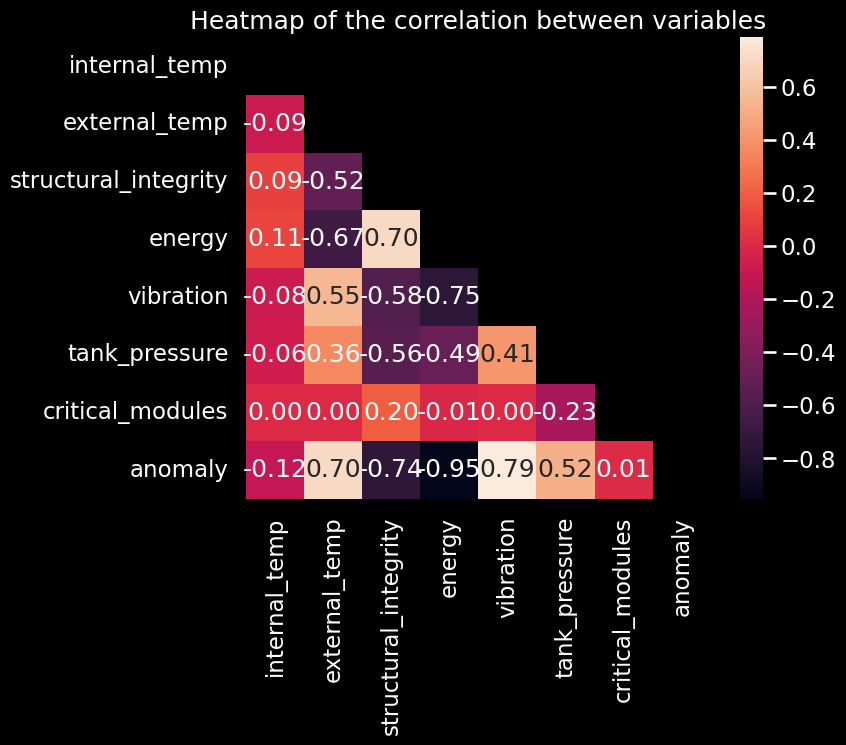

In [5]:
heatmap_plot(df)

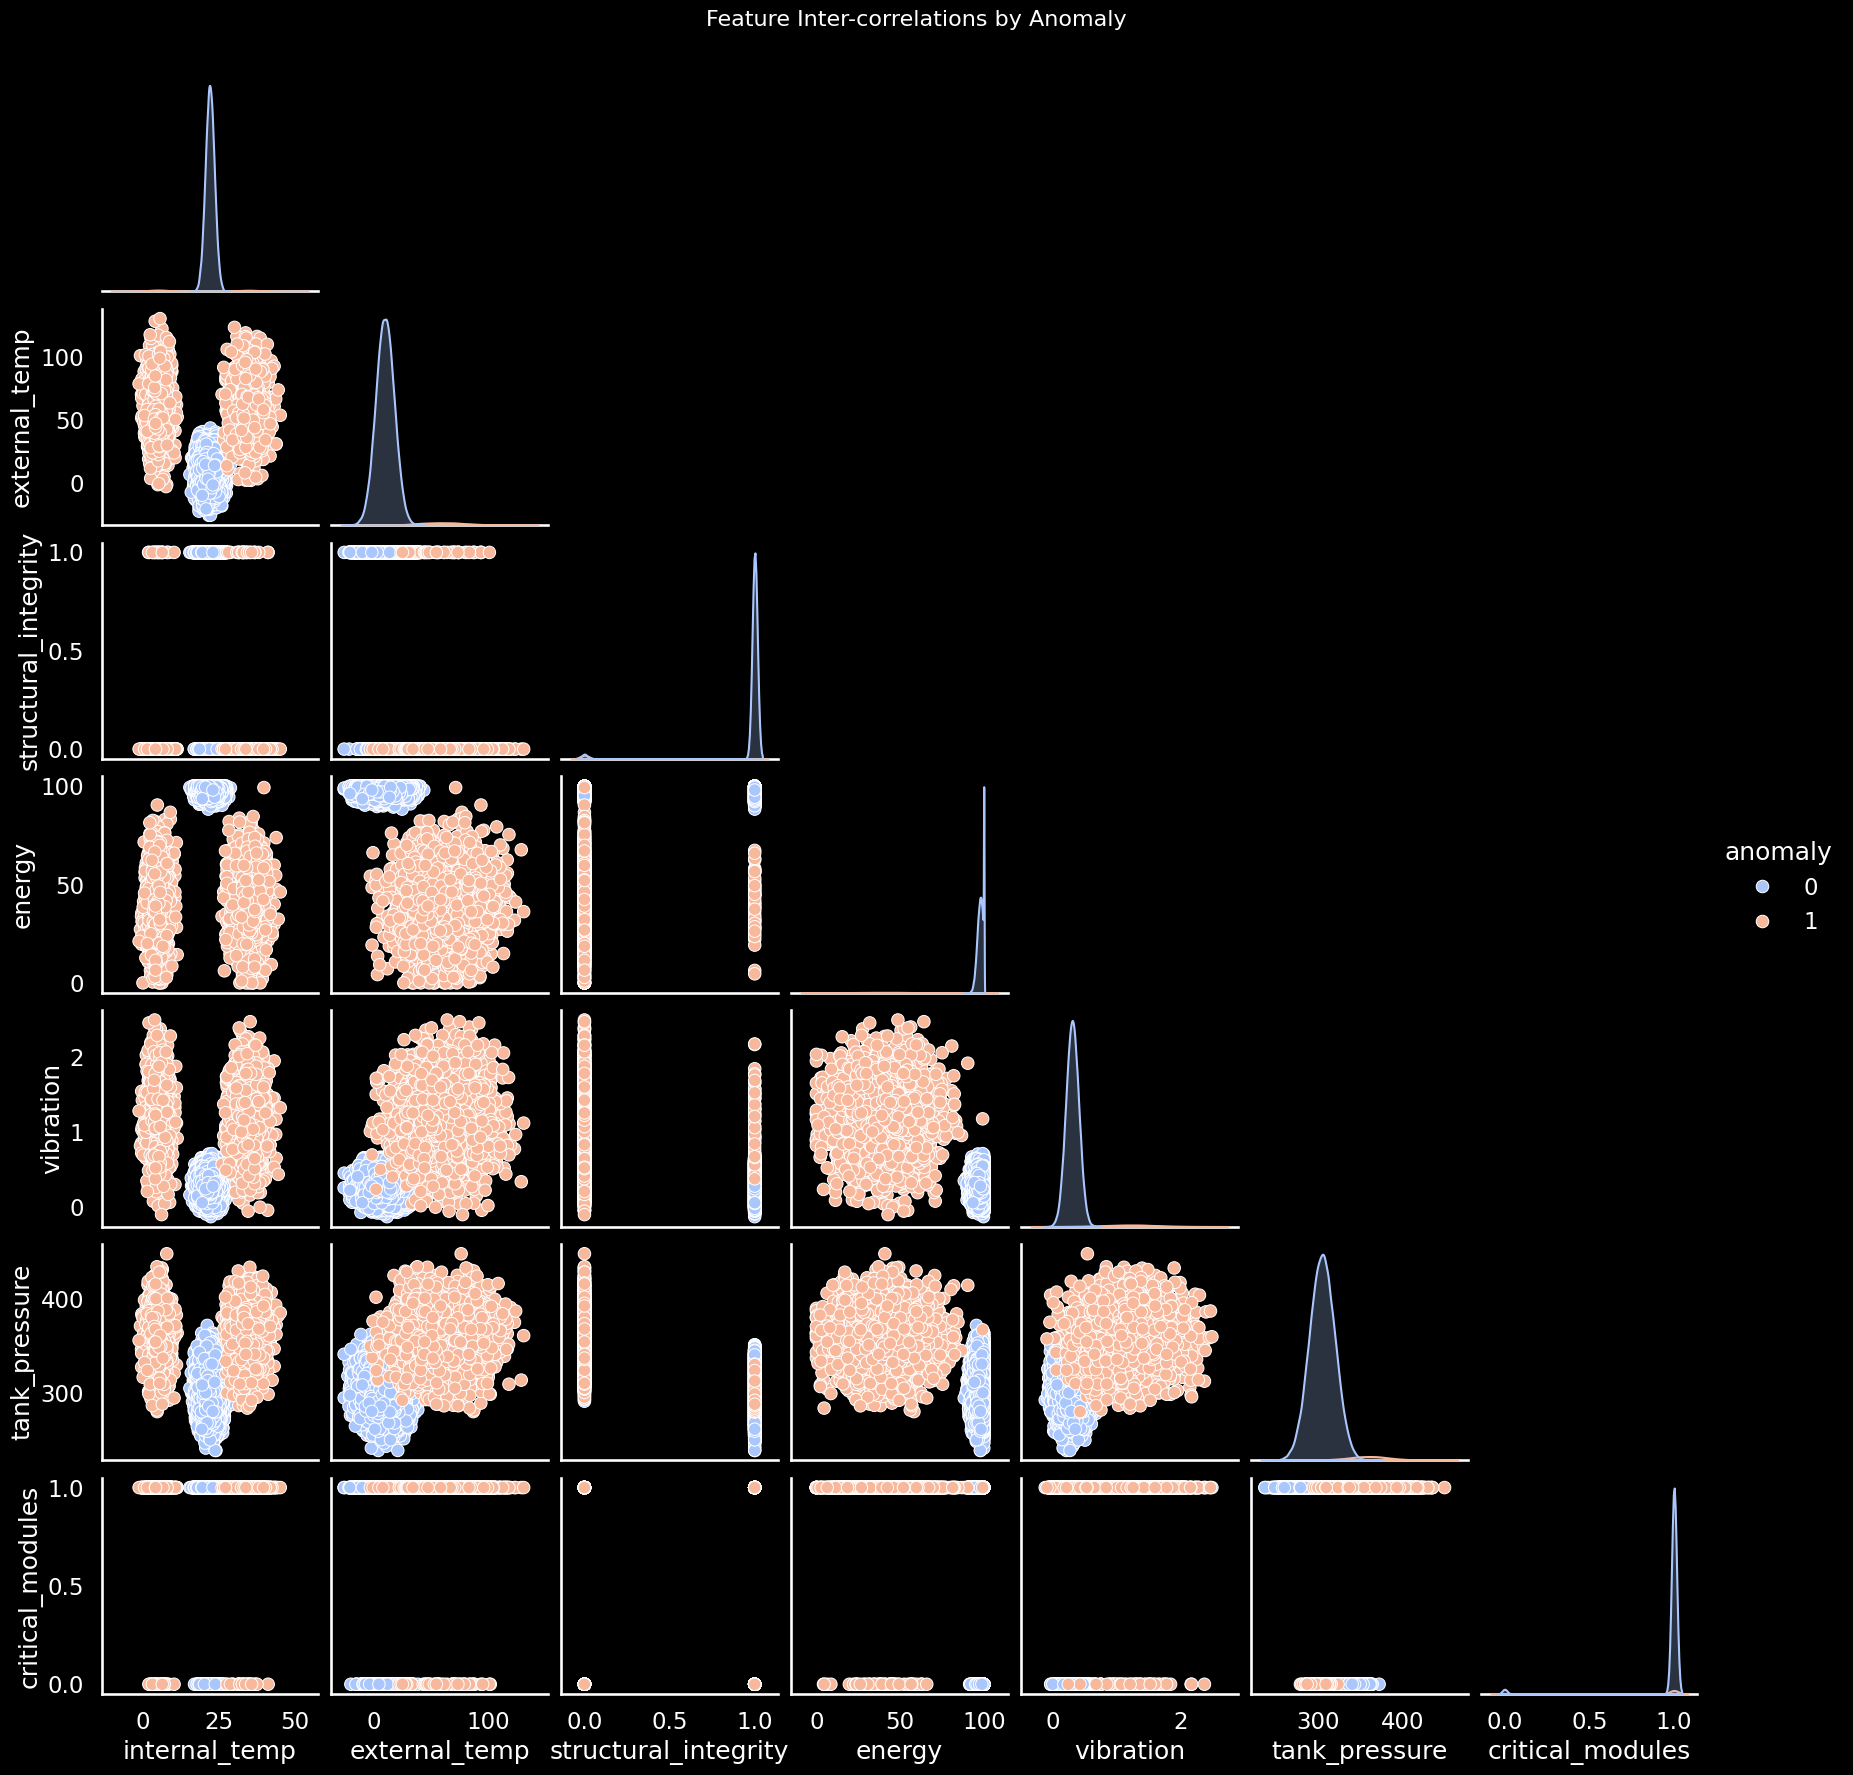

In [6]:
pairplot_data(df)

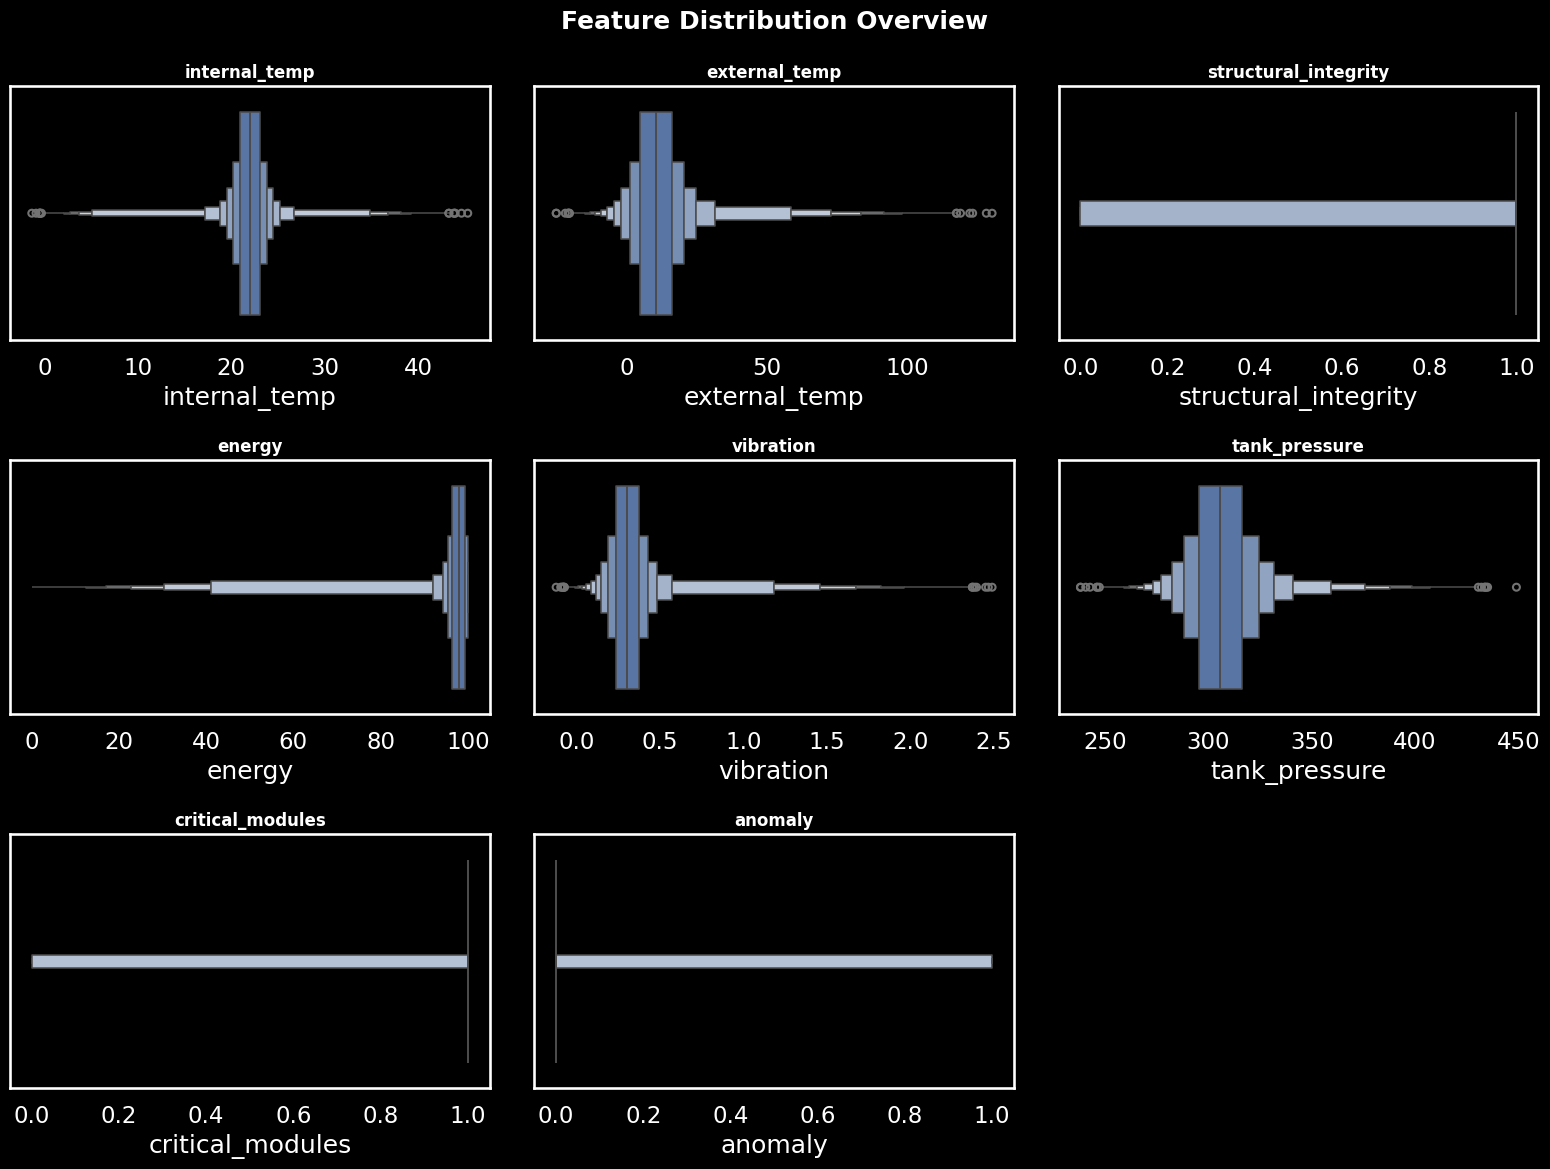

In [7]:
boxplot_analysis(df)

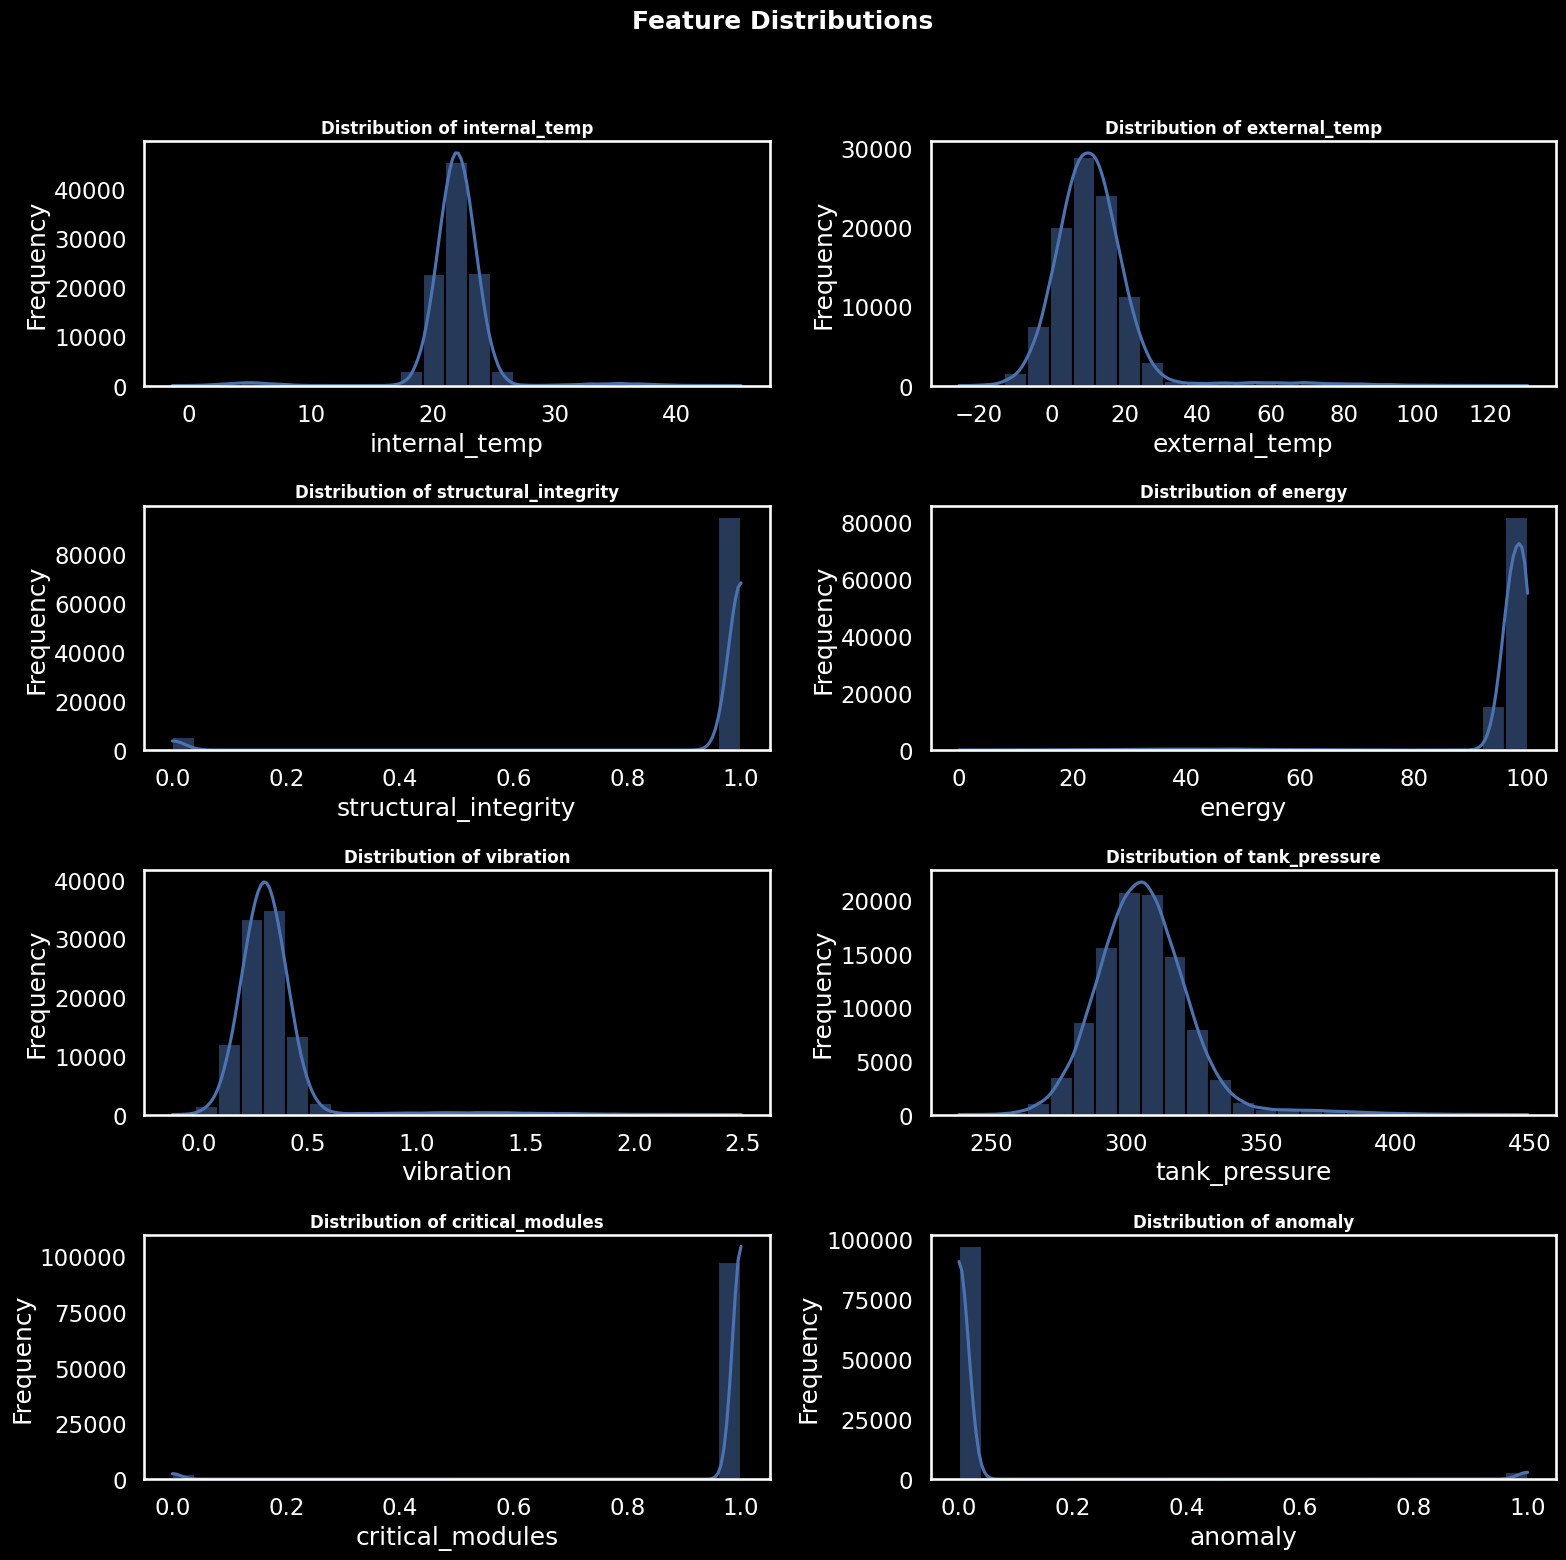

In [8]:
distribution_plot(df)

In [9]:
scatter_3d_anomaly(df.sample(12_000, random_state=42), "tank_pressure", "internal_temp", "vibration")

## 3. Isolation Forest — Do Zero vs. Scikit-learn

Treinamento com split estratificado 80/20, escalonamento via StandardScaler.

In [10]:
X = df.drop(columns=["anomaly"]).values
y = df["anomaly"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
my_model = MyIsolationForest(n_trees=100, sample_size=256)
my_model.fit(X_train)

train_scores = my_model.anomaly_score(X_train)
threshold = np.percentile(train_scores, 97)
test_scores = my_model.anomaly_score(X_test)
preds = np.where(test_scores >= threshold, 1, 0)

print("Scratch Model")
print(classification_report(y_test, preds))
scratch_auc = roc_auc_score(y_test, test_scores)
print(f"ROC AUC: {scratch_auc:.4f}")

Scratch Model
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19400
           1       0.96      0.97      0.96       600

    accuracy                           1.00     20000
   macro avg       0.98      0.98      0.98     20000
weighted avg       1.00      1.00      1.00     20000

ROC AUC: 0.9998


In [12]:
sk_model = IsolationForest(n_estimators=100, max_samples=256, contamination=0.03, random_state=42)
sk_model.fit(X_train)

sk_preds = np.where(sk_model.predict(X_test) == -1, 1, 0)
sk_scores = -sk_model.decision_function(X_test)

print("Sklearn Model")
print(classification_report(y_test, sk_preds))
sk_auc = roc_auc_score(y_test, sk_scores)
print(f"ROC AUC: {sk_auc:.4f}")

Sklearn Model
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19400
           1       0.99      0.99      0.99       600

    accuracy                           1.00     20000
   macro avg       1.00      0.99      0.99     20000
weighted avg       1.00      1.00      1.00     20000

ROC AUC: 1.0000


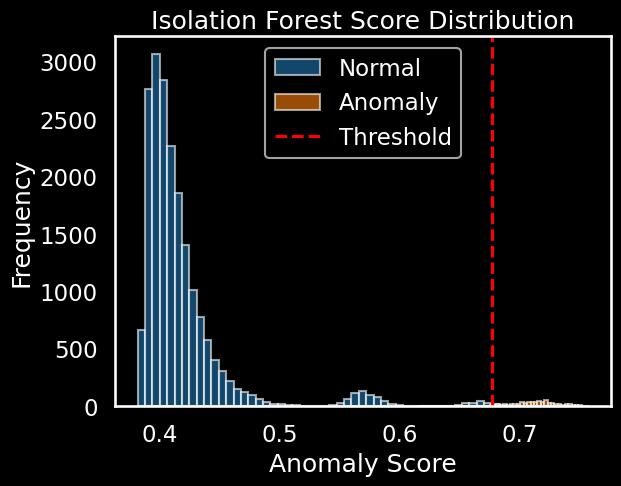

In [13]:
plt.hist(test_scores[y_test == 0], bins=50, alpha=0.6, label="Normal")
plt.hist(test_scores[y_test == 1], bins=50, alpha=0.6, label="Anomaly")
plt.axvline(threshold, color="red", linestyle="--", label="Threshold")
plt.title("Isolation Forest Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

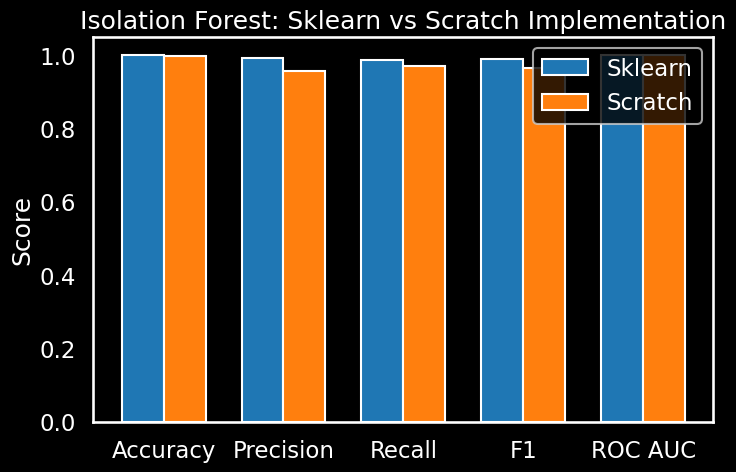

In [14]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC AUC"]

scratch_scores_list = [
    accuracy_score(y_test, preds),
    precision_score(y_test, preds),
    recall_score(y_test, preds),
    f1_score(y_test, preds),
    scratch_auc,
]
sklearn_scores_list = [
    accuracy_score(y_test, sk_preds),
    precision_score(y_test, sk_preds),
    recall_score(y_test, sk_preds),
    f1_score(y_test, sk_preds),
    sk_auc,
]

x = np.arange(len(metrics))
width = 0.35
plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, sklearn_scores_list, width, label="Sklearn")
plt.bar(x + width / 2, scratch_scores_list, width, label="Scratch")
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Isolation Forest: Sklearn vs Scratch Implementation")
plt.legend()
plt.show()

## 4. Pipeline de Decisao GO/NO-GO

Teste com uma leitura normal e uma anomala.

In [15]:
good_sample = {
    "internal_temp": 22.3, "external_temp": 12.0, "structural_integrity": 1,
    "energy": 98.0, "vibration": 0.32, "tank_pressure": 305.0, "critical_modules": 1,
}

bad_sample = {
    "internal_temp": 24.5, "external_temp": 110.0, "structural_integrity": 0,
    "energy": 63.0, "vibration": 0.45, "tank_pressure": 335.0, "critical_modules": 0,
}

for label, sample in [("GOOD", good_sample), ("BAD", bad_sample)]:
    print(f"\n{'='*50}")
    print(f"=== {label} SAMPLE ===")
    launch_decision(sample, my_model, scaler, threshold)


=== GOOD SAMPLE ===

AURORA SIGER — DECISAO DE LANCAMENTO

=== TELEMETRIA ===
internal_temp: OK
external_temp: OK
structural_integrity: OK
energy: OK
vibration: OK
tank_pressure: OK
critical_modules: OK

=== IA ANOMALY CHECK ===
Anomaly Score: 0.3846
IA nao detectou anomalias

=== ANALISE ENERGETICA ===
Energia disponivel: 15.17 kWh
Consumo no lancamento: 0.30 kWh
Autonomia orbital: 12.39 h

 >>> PRONTO PARA DECOLAR <<<

=== BAD SAMPLE ===

AURORA SIGER — DECISAO DE LANCAMENTO

=== TELEMETRIA ===
internal_temp: OK
external_temp: OK
structural_integrity: FAILED
energy: OK
vibration: OK
tank_pressure: OK
critical_modules: FAILED

=== IA ANOMALY CHECK ===
Anomaly Score: 0.7284
IA detectou anomalia

=== ANALISE ENERGETICA ===
Carga insuficiente para lancamento

 >>> DECOLAGEM ABORTADA <<<
